In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski
from rdkit.Chem.GraphDescriptors import AvgIpc
from scipy.stats import spearmanr

# --- Feature Extraction ---
aromatic_query = Chem.MolFromSmarts("a")

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        "mw": Descriptors.MolWt(mol),
        "logp": Crippen.MolLogP(mol),
        "rotors": Lipinski.NumRotatableBonds(mol),
        "ap": len(mol.GetSubstructMatches(aromatic_query)) / mol.GetNumAtoms(),
        "MolLogP": Descriptors.MolLogP(mol),
        "Chi4n": Descriptors.Chi4n(mol),
        "AvgIpc": AvgIpc(mol),
        "TPSA": Descriptors.TPSA(mol),
        "VSA_EState2": Descriptors.VSA_EState2(mol),
        "SlogP_VSA3": Descriptors.SlogP_VSA3(mol),
        "EState_VSA8": Descriptors.EState_VSA8(mol),
    }

# --- Deep Learning Inference ---
def predict_chemeleon(df, smiles_col="SMILES", model_path="../experiments/chemeleon_training"):
    """Runs inference using the Chemprop CheMeleon model saved on disk."""
    tempfile = Path("temp_demo_eval.csv")
    output_tempfile = Path("temp_demo_preds.csv")
    
    # Save target SMILES to a temporary CSV for chemprop to read
    df[[smiles_col]].to_csv(tempfile, index=False)
    
    subprocess.run(
        [
            "chemprop", "predict", 
            "--model-paths", str(model_path), 
            "--preds-path", str(output_tempfile), 
            "--test-path", str(tempfile), 
            "--smiles-column", smiles_col
        ],
        check=True
    )
    
    # Read predictions (Chemprop places predictions in the last column)
    preds_df = pd.read_csv(output_tempfile)
    y_hat = preds_df.iloc[:, -1].values 
    
    # Cleanup temp files
    tempfile.unlink()
    output_tempfile.unlink()
    Path("temp_demo_preds_individual.csv").unlink(missing_ok=True)
    
    return y_hat

# --- Evaluate All Interpretable Models ---
def apply_models(df):
    """Calculates predictions for ESOL, SyMANTIC, and PySR using dataframe vectorization."""
    # ESOL (Refitted)
    df["esol_pred"] = (-6.640e-05 * df["mw"]) - (6.265e-01 * df["logp"]) + \
                      (9.637e-03 * df["rotors"]) - (1.087e+00 * df["ap"]) - 1.037e+00

    # SyMANTIC
    df["symantic_pred"] = (-0.6003928258092548 * df["MolLogP"]) + \
                          (-0.04756373294915526 * (df["VSA_EState2"] - df["SlogP_VSA3"])) + \
                          (-0.015857245648477243 * df["EState_VSA8"]) - 1.0133415331784956

    # PySR
    df["pysr_pred"] = (df["AvgIpc"] + df["MolLogP"]) * (-0.609409521009072)
    
    # CheMeleon (Dynamic execution)
    df["chemeleon_pred"] = predict_chemeleon(df)
    
    return df

def print_metrics(df, dataset_name):
    print(f"--- Metrics for {dataset_name} ---")
    models = ["esol_pred", "symantic_pred", "pysr_pred", "chemeleon_pred"]
    for model in models:
        rmse = np.sqrt(np.mean((df[model] - df["logS"]) ** 2))
        print(f"{model:>15} RMSE: {rmse:.4f}")
        rho, _ = spearmanr(df[model], df["logS"])
        print(f"{model:>15} Spearman Rho: {rho:.4f}")
    print("\n")

2026-04-06T12:45:56 - INFO:chemprop.cli.main - Running in mode 'predict' with args: {'smiles_columns': ['SMILES'], 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'ignore_stereo': False, 'reorder_atoms': False, 'molecule_featurizers': None, 'descriptors_path': None, 'descriptors_columns': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'no_bond_descriptor_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'bond_descriptors_path': None, 'constraints_path': None, 'constraints_to_targets': None, 'use_cuikmolmaker_featurization': False, 'test_path': PosixPath('temp_demo_eval.csv'), 'output': PosixPath('temp_demo_preds.csv'), 'drop_extra_columns': False, 'model_paths': [

Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 
Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 
Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-04-06T12:45:57 - INFO:chemprop.cli.predict - Predictions saved to 'temp_demo_preds.csv'
2026-04-06T12:45:57 - INFO:chemprop.cli.predict - Individual predictions saved to 'temp_demo_preds_individual.csv'
2026-04-06T12:45:57 - INFO:chemprop.cli.predict - Results from model path ../experiments/chemeleon_training/replicate_2/model_0/best.pt are saved under the column name ending with 'model_0'
2026-04-06T12:45:57 - INFO:chemprop.cli.predict - Results from model path ../experiments/chemeleon_training/replicate_1/model_0/best.pt are saved under the column name ending with 'model_1'
2026-04-06T12:45:57 - INFO:chemprop.cli.predict - Results from model path ../experiments/chemeleon_training/replicate_0/model_0/best.pt are saved under the column name ending with 'model_2'


--- Metrics for Fatty Acids ---
      esol_pred RMSE: 0.3574
      esol_pred Spearman Rho: 1.0000
  symantic_pred RMSE: 0.5641
  symantic_pred Spearman Rho: 1.0000
      pysr_pred RMSE: 0.4313
      pysr_pred Spearman Rho: 1.0000
 chemeleon_pred RMSE: 0.7238
 chemeleon_pred Spearman Rho: 1.0000




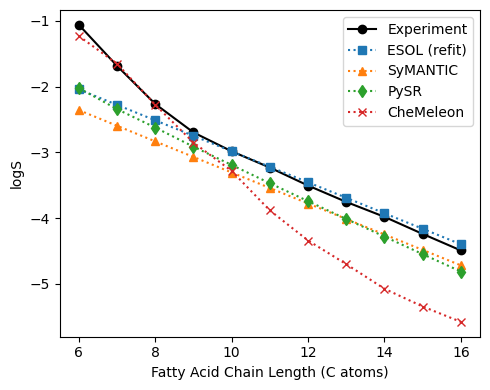

In [2]:
# 1. Load Data
fa_data = pd.read_csv("../data/ralston_hoerr_joc_1942.csv")

# 2. Extract Descriptors
fa_descs = pd.DataFrame(fa_data["SMILES"].apply(calc_descriptors).tolist())
fa_data = pd.concat([fa_data, fa_descs], axis=1)

# 3. Target Conversion (g/100g water at 30°C -> logS)
g_water_at_30_per_ml = 0.99567
ml_per_L = 1000
fa_data["logS"] = np.log10(fa_data["g/100gwaterat30"] * g_water_at_30_per_ml * ml_per_L / 100 / fa_data["mw"])

# 4. Generate Predictions & Calculate Stats
fa_data = apply_models(fa_data)
print_metrics(fa_data, "Fatty Acids")

# 5. Plotting
fa_data["chain_length"] = fa_data["SMILES"].apply(lambda s: s.count("C"))

plt.figure(figsize=(5, 4))
plt.plot(fa_data["chain_length"], fa_data["logS"], label="Experiment", marker="o", linestyle='-', color='black')
plt.plot(fa_data["chain_length"], fa_data["esol_pred"], label="ESOL (refit)", marker="s", linestyle=':')
plt.plot(fa_data["chain_length"], fa_data["symantic_pred"], label="SyMANTIC", marker="^", linestyle=':')
plt.plot(fa_data["chain_length"], fa_data["pysr_pred"], label="PySR", marker="d", linestyle=':')
plt.plot(fa_data["chain_length"], fa_data["chemeleon_pred"], label="CheMeleon", marker="x", linestyle=':')

plt.xlabel("Fatty Acid Chain Length (C atoms)")
plt.ylabel("logS")
plt.legend()
plt.tight_layout()
plt.savefig("../results/fatty_acids_demo.pdf", dpi=300)
plt.show()

2026-04-06T12:46:02 - INFO:chemprop.cli.main - Running in mode 'predict' with args: {'smiles_columns': ['SMILES'], 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'auto', 'devices': 'auto', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'ignore_stereo': False, 'reorder_atoms': False, 'molecule_featurizers': None, 'descriptors_path': None, 'descriptors_columns': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'no_bond_descriptor_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'bond_descriptors_path': None, 'constraints_path': None, 'constraints_to_targets': None, 'use_cuikmolmaker_featurization': False, 'test_path': PosixPath('temp_demo_eval.csv'), 'output': PosixPath('temp_demo_preds.csv'), 'drop_extra_columns': False, 'model_paths': [

Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 
Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-04-06T12:46:02 - INFO:chemprop.cli.predict - Predictions saved to 'temp_demo_preds.csv'
2026-04-06T12:46:02 - INFO:chemprop.cli.predict - Individual predictions saved to 'temp_demo_preds_individual.csv'
2026-04-06T12:46:02 - INFO:chemprop.cli.predict - Results from model path ../experiments/chemeleon_training/replicate_2/model_0/best.pt are saved under the column name ending with 'model_0'
2026-04-06T12:46:02 - INFO:chemprop.cli.predict - Results from model path ../experiments/chemeleon_training/replicate_1/model_0/best.pt are saved under the column name ending with 'model_1'
2026-04-06T12:46:02 - INFO:chemprop.cli.predict - Results from model path ../experiments/chemeleon_training/replicate_0/model_0/best.pt are saved under the column name ending with 'model_2'


Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 
Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 0:00:00 • 0:00:00 0.00it/s 
--- Metrics for Ancenes ---
      esol_pred RMSE: 1.8664
      esol_pred Spearman Rho: 1.0000
  symantic_pred RMSE: 1.7041
  symantic_pred Spearman Rho: 1.0000
      pysr_pred RMSE: 2.1064
      pysr_pred Spearman Rho: 1.0000
 chemeleon_pred RMSE: 0.9708
 chemeleon_pred Spearman Rho: 1.0000




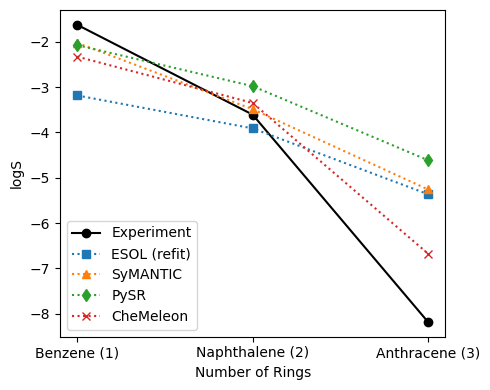

In [3]:
# 1. Load Data
anc_data = pd.read_csv("../data/ancenes.csv")

# 2. Extract Descriptors
anc_descs = pd.DataFrame(anc_data["SMILES"].apply(calc_descriptors).tolist())
anc_data = pd.concat([anc_data, anc_descs], axis=1)

# 3. Target Conversion (mg/L -> logS)
g_per_mg = 1 / 1000
anc_data["logS"] = np.log10(anc_data["mg/L"] * g_per_mg / anc_data["mw"])

# 4. Generate Predictions & Calculate Stats
anc_data = apply_models(anc_data)
print_metrics(anc_data, "Ancenes")

# 5. Plotting
anc_data["number_of_rings"] = [1, 2, 3] # Benzene, Naphthalene, Anthracene

plt.figure(figsize=(5, 4))
plt.plot(anc_data["number_of_rings"], anc_data["logS"], label="Experiment", marker="o", linestyle='-', color='black')
plt.plot(anc_data["number_of_rings"], anc_data["esol_pred"], label="ESOL (refit)", marker="s", linestyle=':')
plt.plot(anc_data["number_of_rings"], anc_data["symantic_pred"], label="SyMANTIC", marker="^", linestyle=':')
plt.plot(anc_data["number_of_rings"], anc_data["pysr_pred"], label="PySR", marker="d", linestyle=':')
plt.plot(anc_data["number_of_rings"], anc_data["chemeleon_pred"], label="CheMeleon", marker="x", linestyle=':')

plt.xlabel("Number of Rings")
plt.xticks([1, 2, 3], ["Benzene (1)", "Naphthalene (2)", "Anthracene (3)"])
plt.ylabel("logS")
plt.legend()
plt.tight_layout()
plt.savefig("../results/ancenes_demo.pdf", dpi=300)
plt.show()